In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as sps
import numpy as np

In [ ]:
#Задание 1
# Из данных мы знаем, что в-ть правильного ответа на вопрос сложности "как на работе" профи это 98%, а непрофи - 90%.
# Обозначим как p_s = 0.98, p_p = 0.9. В терминах вероятности это значит, что сложность имеет биномиальное распределение, тк кандидат даёт бинарный ответ.

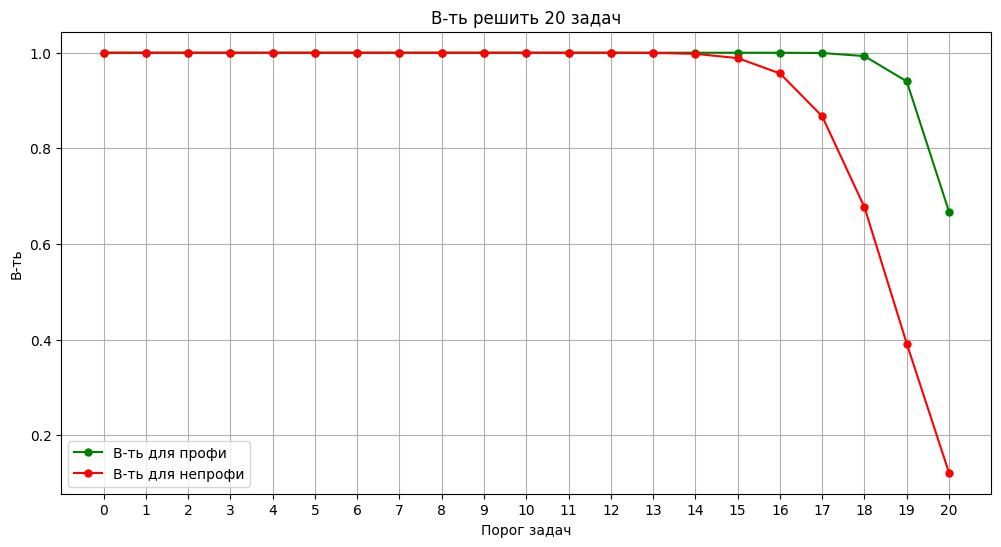

In [33]:
#Задание 2
#Построение графика
p_s = 0.98
p_p = 0.9
n = 20

data = []

for k in range(n + 1):
  p_sk = 1 -sps.binom.cdf(k - 1, n, p_s)
  p_pk = 1 - sps.binom.cdf(k - 1, n, p_p)
  data.append([k, p_sk, p_pk])



data = pd.DataFrame(data, columns=['Порог', 'В-ть прохода профи', 'В-ть прохода непрофи'])
data

plt.figure(figsize=(12, 6))
plt.plot(data['Порог'], data['В-ть прохода профи'], color='green', marker='o', markersize=5, label='В-ть для профи')
plt.plot(data['Порог'], data['В-ть прохода непрофи'], color='red', marker='o', markersize=5, label='В-ть для непрофи')
plt.xticks(data['Порог'][::1])
plt.grid()


plt.title('В-ть решить 20 задач')
plt.xlabel('Порог задач')
plt.ylabel('В-ть')
plt.legend()


plt.show()

In [ ]:
# У нас есть условие, что в-ть прохода профи должна быть не менее 80%. Из графика видно, что на 19ом вопросе профи всё еще проходит, а слабый уже валится.
# Тогда порог будет 19.
# В-ть на 19ом вопросе
# Непрофи 0.391747
# Профи 0.940101

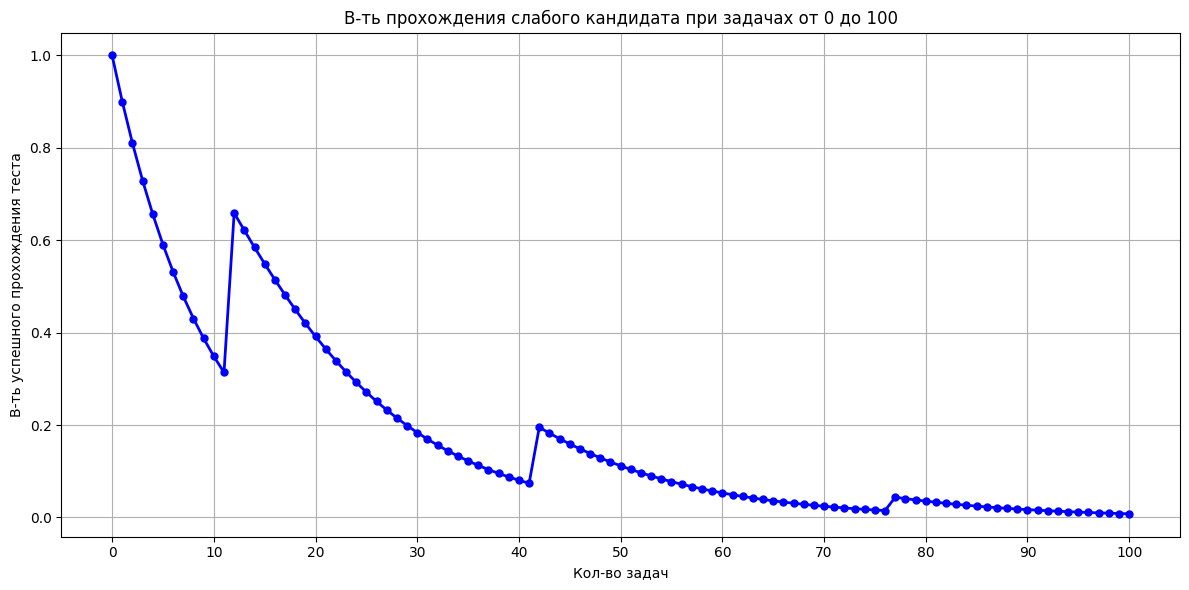

In [34]:
#Задания 3-4
# Посмотрим как справляется кандидат на вопросах от 0 до 100, учтя все условия.
# Условие, что вероятность прохождения теста сильным
# кандидатом должна быть не меньше 80% : это k = ppf(0.2) - 1

# тогда слабый пройдет это с вероятностью p_p2 = 1 - cdf(k)

#на графике покажем как это происходит и выберем проходной порог

p_p2 = []

for n in range(101):
  k = sps.binom.ppf(0.2, n, p_s)
  p_p2.append(1 - sps.binom.cdf(k-1, n, p_p))



tasks = [i for i in range(100+1)]
plt.figure(figsize=(12,6))
plt.plot(tasks, p_p2, marker='o', linestyle='-', linewidth=2, color='blue', markersize=5)
plt.title('В-ть прохождения слабого кандидата при задачах от 0 до 100')
plt.xlabel('Кол-во задач')
plt.ylabel('В-ть успешного прохождения теста')
plt.xticks(np.arange(0, 101, 10))
plt.grid()
plt.tight_layout()
plt.show()


In [24]:
#Из графика видно скачкообразные промежутки. Это происходит, когда в-ть профи ниже 80%, порог падает, поднимается в-ть непрофи
#Найдем минимальное кол-во задач, где выполняются все условия
for n in range(100+1):
  if p_p2[n] <= 0.3:
    print(n)
    break

24


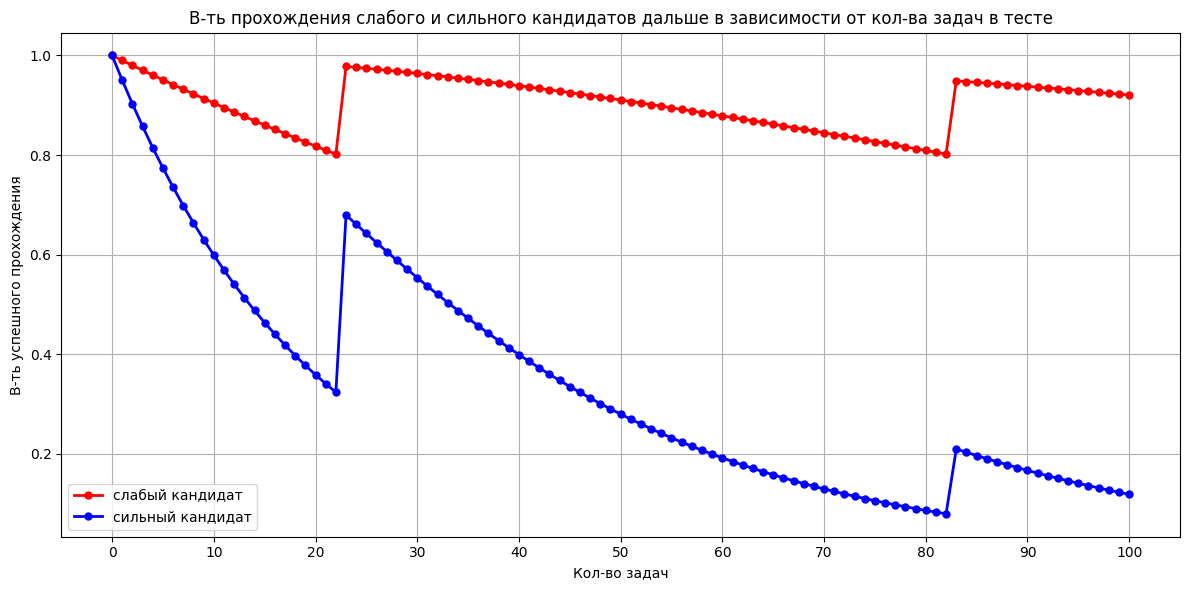

In [35]:
#Задача 5
#Из условия сложность "Проще, чем на работе":
p_s = 0.99
p_p = 0.95
#По аналогии с заданиями 1-2 построим график, только для 0-100 задач

p_s2 = []
p_p2 = []

for n in range(101):
  k = sps.binom.ppf(0.2, n, p_s)
  p_s2.append(1 - sps.binom.cdf(k-1, n, p_s))
  p_p2.append(1 - sps.binom.cdf(k-1, n, p_p))

plt.figure(figsize=(12,6))
plt.plot(range(101), p_s2, marker='o', linewidth=2, color='red', markersize=5, label='слабый кандидат')
plt.plot(range(101), p_p2, marker='o', linewidth=2, color='blue', markersize=5, label='сильный кандидат')

plt.title('В-ть прохождения слабого и сильного кандидатов дальше в зависимости от кол-ва задач в тесте')
plt.xlabel('Кол-во задач')
plt.ylabel('В-ть успешного прохождения')
plt.xticks(np.arange(0, 101, 10))
plt.legend()

plt.grid()
plt.tight_layout()
plt.show()


In [28]:
#Минимальное кол-во задач
for n in range(101):
  if p_p2[n] <= 0.3:
    print(n)
    break

49


In [29]:
#Оптимальный порог при всех условиях
k = sps.binom.ppf(0.2, 49, p_s)
k.item()

48.0

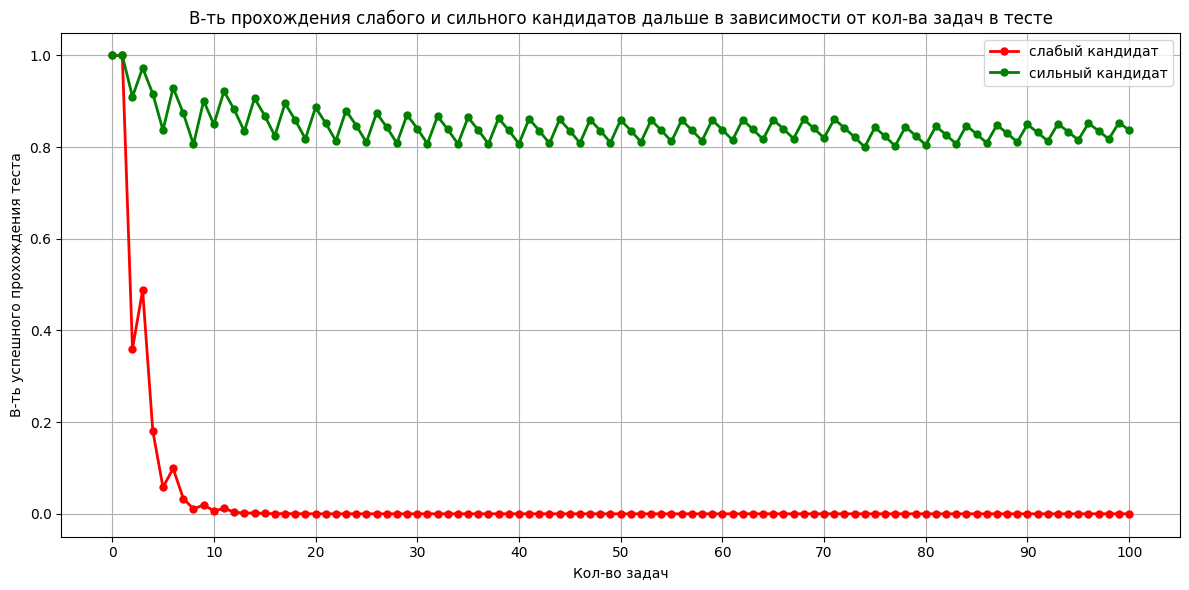

In [36]:
#Задача 6
#Рассмотрим в-ти при уровне сложности "Сложнее, чем на работе"

p_s = 0.7
p_w = 0.2
p_s2 = []
p_p2 = []

for n in range(101):
  k = sps.binom.ppf(0.2, n, p_s)
  p_s2.append(1 - sps.binom.cdf(k-1, n, p_s)) #добавили в-ти в списочек
  p_p2.append(1 - sps.binom.cdf(k-1, n, p_w))

plt.figure(figsize=(12,6))
plt.plot(range(101), p_p2, marker='o', linewidth=2, color='red', markersize=5, label='слабый кандидат')
plt.plot(range(101), p_s2, marker='o', linewidth=2, color='green', markersize=5, label='сильный кандидат')
plt.title('В-ть прохождения слабого и сильного кандидатов дальше в зависимости от кол-ва задач в тесте')

plt.xlabel('Кол-во задач')
plt.ylabel('В-ть успешного прохождения теста')
plt.xticks(np.arange(0, 101, 10))
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [31]:
#Мин-ое кол-во задач
for n in range(101):
  if p_p2[n] <= 0.3:
    print(n)
    break

4


In [32]:
#Порог
k = sps.binom.ppf(0.2, 4, p_s)
k.item()

2.0

In [ ]:
#Задание 7
#Думаю, оптимальнее всего "как на работе", тк если легче, то слишком много задач, а если больше, то тяжело оценивать